# Phishing URL Detection using Traditional Machine Learning

This notebook develops and evaluates several traditional machine learning models for phishing URL detection using engineered URL features.

The workflow includes:

- Loading and exploring the engineered dataset
- Train/validation/test splitting
- Building machine learning pipelines
- Cross-validation for model comparison
- Training the candidate models
- Evaluating performance on the test set
- Selecting and saving the best-performing model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, accuracy_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the engineered dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
new_df = pd.read_csv("/content/drive/MyDrive/phishing-url-detection/cleaned_phishing_dataset_with_features.csv")
new_df

,url,label,url_length,domain_length,path_length,query_length,num_dots,num_hyphens,num_underscores,num_slashes,...,contains_secure,contains_bank,contains_paypal,contains_confirm,contains_password,contains_webscr,contains_ebay,contains_wp,contains_admin,entropy
0,https://www.google.com,1,22.0,14.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.663533
1,https://www.youtube.com,1,23.0,15.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.762267
2,https://www.facebook.com,1,24.0,16.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.855389
3,https://www.baidu.com,1,21.0,13.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.880180
4,https://www.wikipedia.org,1,25.0,17.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.813661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781895,https://www.skincareliving.com,1,30.0,22.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.189898
781896,https://www.winchester.gov.uk,1,29.0,21.0,0.0,0.0,3.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.978334
781897,https://www.nononsensedesign.be,1,31.0,23.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.652115
781898,https://patient-cell-40f5.updatedlogmylogin.wo...,0,56.0,47.0,1.0,0.0,3.0,2.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.575324


In [3]:
# Check for missing values
new_df.isna().sum()

url                  0
label                0
url_length           0
domain_length        0
path_length          0
query_length         0
num_dots             0
num_hyphens          0
num_underscores      0
num_slashes          0
num_questionmarks    0
num_equal            0
num_at               0
num_ampersand        0
num_percent          0
num_digits           0
has_https            0
has_ip               0
has_port             0
num_subdomains       0
contains_login       0
contains_signin      0
contains_verify      0
contains_account     0
contains_update      0
contains_secure      0
contains_bank        0
contains_paypal      0
contains_confirm     0
contains_password    0
contains_webscr      0
contains_ebay        0
contains_wp          0
contains_admin       0
entropy              0
dtype: int64

In [4]:
# Check correlations between features and the target label
corr = new_df.corr(numeric_only=True)["label"].sort_values(ascending=False)
corr

label                1.000000
has_https            0.838243
num_subdomains       0.335632
entropy              0.130520
num_dots             0.118538
num_hyphens          0.111824
path_length          0.096185
num_underscores      0.079586
num_slashes          0.019406
contains_ebay        0.017543
url_length           0.014483
domain_length       -0.008249
num_percent         -0.011474
num_questionmarks   -0.011691
contains_password   -0.015617
num_equal           -0.019220
contains_bank       -0.025987
contains_webscr     -0.030675
num_ampersand       -0.039838
contains_verify     -0.050020
contains_confirm    -0.053726
contains_signin     -0.061753
has_port            -0.061822
query_length        -0.069160
contains_paypal     -0.069622
num_digits          -0.077304
contains_update     -0.080504
contains_account    -0.080545
num_at              -0.082669
has_ip              -0.088998
contains_secure     -0.097999
contains_admin      -0.116589
contains_wp         -0.158206
contains_l

In [5]:
# Check relationship between 'has_https' and the target label.
pd.crosstab(new_df["has_https"], new_df["label"])

label,0,1
has_https,,
0.0,199399,2476
1.0,53311,526714


> Observation: The dataset is heavily biased toward HTTPS. URLs using HTTPS are overwhelmingly associated with the legitimate class, making `has_https` an unusually dominant feature. To better evaluate the contribution of the remaining engineered features, this feature is excluded from model training.

In [6]:
X = new_df.drop(columns=["url", "label", "has_https"])
y = new_df["label"]

print(f"Feature matrix shape: {X.shape}")
print("\nClass balance:")
print(y.value_counts().round(3))


Feature matrix shape: (781900, 32)

Class balance:
label
1    529190
0    252710
Name: count, dtype: int64


## 2. Train / Validation / Test split

- **Train** — used for cross-validated model comparison and final fitting
- **Validation** — used for early stopping (XGBoost/LightGBM) and threshold checks
- **Test** — touched only once, at the very end

All splits are stratified to preserve the ~2:1 class ratio.

In [7]:
#
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Imbalance ratio, used by XGBoost's scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight (neg/pos): {scale_pos_weight:.3f}")


Train: 547,330 | Val: 117,285 | Test: 117,285
scale_pos_weight (neg/pos): 0.478


## 3. Model pipelines

Each model is wrapped in a `Pipeline` so scaling (where it is needed) is fit only on training folds — no leakage during cross-validation.

- **Logistic Regression** — scaled, L2-regularized, `class_weight="balanced"`
- **Random Forest** — no scaling needed; depth/leaf constraints added to prevent memorization
- **XGBoost / LightGBM** — no scaling needed; `scale_pos_weight` / `class_weight` handle imbalance, conservative depth + regularization guard against overfitting, and both are fit later with early stopping

In [8]:
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=1.0,
            penalty="l2",
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "XGBoost": Pipeline([
        ("clf", XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "LightGBM": Pipeline([
        ("clf", LGBMClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
}


## 4. Cross-validation comparison


Five-fold stratified cross-validation is used to obtain a more reliable estimate of model performance while preserving the original class distribution in every fold.

In [9]:
# Create a 5-fold stratified cross-validation object
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Metrics to evaluate
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Store the average results for each model
cv_results = {}

# Evaluate each pipeline
for model_name, pipeline in pipelines.items():

    # Cross-validation
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metrics,
        n_jobs=-1
    )

    # Compute the mean score for each metric
    average_scores = {}
    for metric in metrics:
        average_scores[metric] = scores[f"test_{metric}"].mean()

    cv_results[model_name] = average_scores
    print(f"\n{model_name}")
    for metric, value in average_scores.items():
        print(f"  {metric:<10}: {value:.3f}")

# Convert the results into a DataFrame for easy comparison
cv_results_df = pd.DataFrame(cv_results).T
cv_results_df



Logistic Regression
  accuracy  : 0.856
  precision : 0.906
  recall    : 0.878
  f1        : 0.892
  roc_auc   : 0.898

Random Forest
  accuracy  : 0.878
  precision : 0.883
  recall    : 0.944
  f1        : 0.913
  roc_auc   : 0.925

XGBoost
  accuracy  : 0.931
  precision : 0.952
  recall    : 0.945
  f1        : 0.949
  roc_auc   : 0.976

LightGBM
  accuracy  : 0.930
  precision : 0.951
  recall    : 0.945
  f1        : 0.948
  roc_auc   : 0.975


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.856284,0.906396,0.878253,0.892053,0.897516
Random Forest,0.877947,0.883389,0.944319,0.912837,0.924734
XGBoost,0.930610,0.952300,0.944800,0.948534,0.975805
LightGBM,0.929949,0.951313,0.944854,0.948072,0.975295


## 5. Model Training

Logistic Regression and Random Forest are fit directly on the training set. XGBoost and LightGBM are fit with the validation set as an early-stopping monitor, so boosting halts once validation loss stops improving — the single biggest overfitting guard for these models.

In [10]:
fitted_models = {}

# Logistic Regression
fitted_models["Logistic Regression"] = pipelines["Logistic Regression"].fit(X_train, y_train)

# Random Forest
fitted_models["Random Forest"] = pipelines["Random Forest"].fit(X_train, y_train)

# XGBoost with early stopping
xgb_clf = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    early_stopping_rounds=50,
    n_jobs=-1, random_state=RANDOM_STATE,
)
xgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
fitted_models["XGBoost"] = xgb_clf
print(f"XGBoost stopped at {xgb_clf.best_iteration} trees")

# LightGBM with early stopping
import lightgbm as lgb

lgbm_clf = LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    class_weight="balanced",
    n_jobs=-1, random_state=RANDOM_STATE,
)
lgbm_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
fitted_models["LightGBM"] = lgbm_clf
print(f"LightGBM stopped at {lgbm_clf.best_iteration_} trees")


XGBoost stopped at 499 trees


C:\Users\arian\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 370433, number of negative: 176897
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1538
[LightGBM] [Info] Number of data points in the train set: 547330, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

## 6. Model Evaluation

Each model is evaluated **once** on the test set — precision/recall/F1 per class, ROC-AUC, and a confusion matrix.


Logistic Regression
              precision    recall  f1-score   support

    phishing       0.77      0.81      0.79     37907
  legitimate       0.91      0.88      0.89     79378

    accuracy                           0.86    117285
   macro avg       0.84      0.85      0.84    117285
weighted avg       0.86      0.86      0.86    117285

ROC-AUC: 0.899


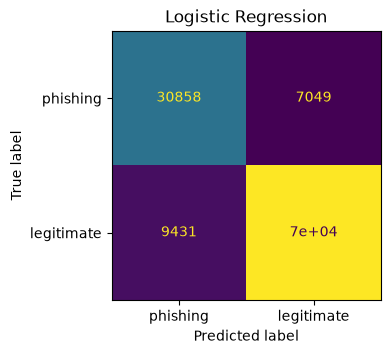


Random Forest
              precision    recall  f1-score   support

    phishing       0.86      0.74      0.79     37907
  legitimate       0.88      0.95      0.91     79378

    accuracy                           0.88    117285
   macro avg       0.87      0.84      0.85    117285
weighted avg       0.88      0.88      0.87    117285

ROC-AUC: 0.922


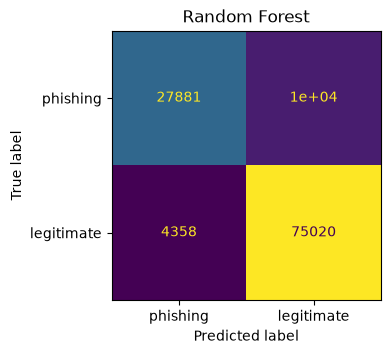


XGBoost
              precision    recall  f1-score   support

    phishing       0.88      0.90      0.89     37907
  legitimate       0.95      0.94      0.95     79378

    accuracy                           0.93    117285
   macro avg       0.92      0.92      0.92    117285
weighted avg       0.93      0.93      0.93    117285

ROC-AUC: 0.975


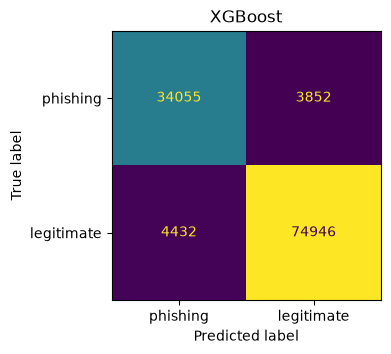


LightGBM
              precision    recall  f1-score   support

    phishing       0.88      0.90      0.89     37907
  legitimate       0.95      0.94      0.95     79378

    accuracy                           0.93    117285
   macro avg       0.92      0.92      0.92    117285
weighted avg       0.93      0.93      0.93    117285

ROC-AUC: 0.974


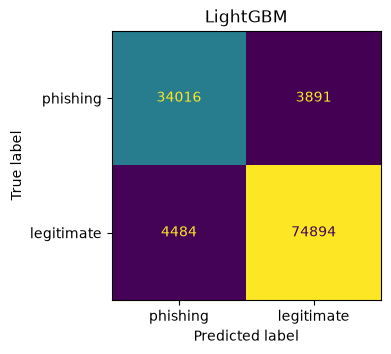

In [11]:
test_summary = {}

for model_name, model in fitted_models.items():

    # Make predictions
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    test_summary[model_name] = {
        "f1": f1,
        "roc_auc": roc_auc
    }

    # Print classification report
    print(f"\n{'=' * 60}")
    print(model_name)
    print("=" * 60)
    print(classification_report(
        y_test,
        predictions,
        target_names=["phishing", "legitimate"]
    ))
    print(f"ROC-AUC: {roc_auc:.3f}")

    # Display confusion matrix
    fig, ax = plt.subplots(figsize=(4, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["phishing", "legitimate"],
        ax=ax,
        colorbar=False
    )

    ax.set_title(model_name)
    plt.tight_layout()
    plt.show()

In [12]:
# Pick the best model
best_model = max(test_summary, key=lambda k: test_summary[k]["roc_auc"])
print(f"Best model: {best_model}")

Best model: XGBoost


In [13]:
# Check for overfitting
test_pred = fitted_models[best_model].predict(X_test)
train_pred = fitted_models[best_model].predict(X_train)

accuracy_train = accuracy_score(y_train, train_pred)
accuracy_test = accuracy_score(y_test, test_pred)

difference = accuracy_train - accuracy_test

print(f"Train accuracy: {accuracy_train:.4f}")
print(f"Test accuracy : {accuracy_test:.4f}")
print(f"Accuracy gap  : {difference:.4f}")

Train accuracy: 0.9321
Test accuracy : 0.9294
Accuracy gap  : 0.0027


That is a very small gap and suggests your XGBoost model is generalizing well rather than memorizing the training data.

## 7. Save the Best Model

The best-performing model is serialized using the `joblib` library, allowing it to be loaded later for inference or deployment without retraining.

In [15]:
import joblib

# Save the best model
joblib.dump(fitted_models[best_model], "phishing_url_detector.joblib")

['phishing_url_detector.joblib']

> **Note:** during model evaluation, the `has_https` feature exhibited a very strong association with the target class. To determine whether the model relied excessively on this feature, an additional experiment was performed with `has_https` removed. Model performance decreased from approximately 99.9% accuracy to 93.0% accuracy (XGBoost), indicating that while HTTPS status is highly informative, the remaining engineered features still provide substantial predictive power. The final model continued to generalize well, with nearly identical training (93.27%) and testing (93.00%) accuracy, suggesting minimal overfitting.